In [1]:
import os
import numpy as np
import tifffile as tiff
from collections import Counter
import cv2

DATASET_DIR = os.path.expanduser('~/data/MADOS')
SPLITS_DIR = os.path.join(DATASET_DIR, 'splits')
IMG_SIZE = (240, 240)

def get_class_distribution(split_file):
    with open(split_file, 'r') as f:
        entries = [line.strip() for line in f.readlines()]

    class_counts = Counter()

    for entry in entries:
        try:
            parts = entry.split('_')
            scene_name = f"{parts[0]}_{parts[1]}"
            crop_num = parts[-1]
            mask_path = os.path.join(DATASET_DIR, scene_name, "10", f"{scene_name}_L2R_cl_{crop_num}.tif")

            mask = tiff.imread(mask_path)
            mask = cv2.resize(mask, IMG_SIZE, interpolation=cv2.INTER_NEAREST)
            unique, counts = np.unique(mask, return_counts=True)
            class_counts.update(dict(zip(unique, counts)))

        except Exception as e:
            print(f"Skipping {entry}: {e}")

    return class_counts

# Run for training set
counts = get_class_distribution(os.path.join(SPLITS_DIR, "train_X.txt"))

total_pixels = sum(counts.values())
print("Class distribution (class index -> pixel count):")
for cls, count in sorted(counts.items()):
    percentage = (count / total_pixels) * 100
    print(f"Class {cls}: {percentage:.4f}%")



Class distribution (class index -> pixel count):
Class 0: 99.0770%
Class 1: 0.0031%
Class 2: 0.0022%
Class 3: 0.0031%
Class 4: 0.0013%
Class 5: 0.0072%
Class 6: 0.1703%
Class 7: 0.3210%
Class 8: 0.1905%
Class 9: 0.0006%
Class 10: 0.1079%
Class 11: 0.0848%
Class 12: 0.0121%
Class 13: 0.0085%
Class 14: 0.0016%
Class 15: 0.0089%


In [2]:
import tensorflow as tf
import numpy as np
import cv2
import os
import tifffile as tiff

# Dataset root
DATASET_DIR = os.path.expanduser('~/data/MADOS')
SPLITS_DIR = os.path.join(DATASET_DIR, 'splits')

IMG_SIZE = (240, 240)

def load_image_mask(scene_name, crop_num):
    scene_folder = os.path.join(DATASET_DIR, scene_name, "10")

    rgb_path = os.path.join(scene_folder, f"{scene_name}_L2R_rgb_{crop_num}.png")
    cl_path = os.path.join(scene_folder, f"{scene_name}_L2R_cl_{crop_num}.tif")

    if not (os.path.exists(rgb_path) and os.path.exists(cl_path)):
        raise FileNotFoundError(f"Missing image or mask for {scene_name} crop {crop_num}")

    # Load RGB
    image = cv2.imread(rgb_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, IMG_SIZE)
    image = image / 255.0  # Normalize

    # Load mask
    mask = tiff.imread(cl_path)
    mask = cv2.resize(mask, IMG_SIZE, interpolation=cv2.INTER_NEAREST)
    mask = mask.astype(np.uint8)

    return image, mask


def augment(image, mask):
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask = tf.image.flip_left_right(tf.expand_dims(mask, axis=-1))
        mask = tf.squeeze(mask, axis=-1)
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_up_down(image)
        mask = tf.image.flip_up_down(tf.expand_dims(mask, axis=-1))
        mask = tf.squeeze(mask, axis=-1)
    if tf.random.uniform(()) > 0.5:
        image = tf.image.random_brightness(image, max_delta=0.1)
        image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    return image, mask

def create_dataset(split_file, batch_size=32, augment_data=False):
    with open(split_file, 'r') as f:
        raw_scene_crops = [line.strip() for line in f.readlines()]

    def generator():
        for entry in raw_scene_crops:
            try:
                parts = entry.split('_')
                scene_name = f"{parts[0]}_{parts[1]}"  # e.g. "Scene_0"
                crop_num = parts[-1]                   # e.g. "1"
                img, mask = load_image_mask(scene_name, crop_num)
                yield img, mask
            except Exception as e:
                print(f"[Warning] Skipping {entry}: {e}")

    dataset = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(240, 240, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(240, 240), dtype=tf.uint8),
        )
    )

    if augment_data:
        dataset = dataset.map(augment, num_parallel_calls=tf.data.AUTOTUNE)

    return dataset.shuffle(100).batch(batch_size).prefetch(tf.data.AUTOTUNE)

2025-08-04 18:27:43.970055: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-04 18:27:43.979204: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754342863.989279  494397 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754342863.992370  494397 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1754342864.000157  494397 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [3]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D, Concatenate, Input, BatchNormalization, ReLU

def conv_block(x, filters):
    x = Conv2D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Conv2D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    return x

def unet_model(input_shape=(240, 240, 3), num_classes=16):
    inputs = Input(input_shape)

    # Encoder
    c1 = conv_block(inputs, 64)
    p1 = MaxPooling2D()(c1)

    c2 = conv_block(p1, 128)
    p2 = MaxPooling2D()(c2)

    # Bottleneck
    b = conv_block(p2, 256)

    # Decoder
    u1 = UpSampling2D()(b)
    u1 = Concatenate()([u1, c2])
    c3 = conv_block(u1, 128)

    u2 = UpSampling2D()(c3)
    u2 = Concatenate()([u2, c1])
    c4 = conv_block(u2, 64)

    # Output layer: kernel size 1, num_classes filters, softmax activation
    outputs = Conv2D(num_classes, 1, padding='same', activation='softmax')(c4)

    return tf.keras.Model(inputs, outputs)

# Test output shape
if __name__ == "__main__":
    model = unet_model()
    model.summary()
    print("Output shape:", model.output_shape)  # Should be (None, 240, 240, 16)


I0000 00:00:1754342865.364221  494397 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9860 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 240, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 240, 240,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 240, 240,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 240, 240,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 240, 240,  │     36,928 │ re_lu[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 240, 240,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 240, 240,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 120, 120,  │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 120, 120,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 120, 120,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 120, 120,  │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 120, 120,  │    147,584 │ re_lu_2[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 120, 120,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 120, 120,  │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 60, 60,    │          0 │ re_lu_3[0][0]     │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 60, 60,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 60, 60,    │      1,024 │ conv2d_4[0][0]  

 Total params: 1,889,232 (7.21 MB)

 Trainable params: 1,886,672 (7.20 MB)

 Non-trainable params: 2,560 (10.00 KB)

Output shape: (None, 240, 240, 16)


In [4]:
import os
import tensorflow as tf
from tensorflow.keras.losses import SparseCategoricalCrossentropy

# ---- Custom Metric ----
class CustomMeanIoU(tf.keras.metrics.Metric):
    def __init__(self, num_classes, name="custom_mean_iou", **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.mean_iou = tf.keras.metrics.MeanIoU(num_classes=num_classes)

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.argmax(y_pred, axis=-1)
        y_true = tf.cast(y_true, tf.int32)
        y_pred = tf.reshape(y_pred, [-1])
        y_true = tf.reshape(y_true, [-1])
        self.mean_iou.update_state(y_true, y_pred)

    def result(self):
        return self.mean_iou.result()

    def reset_states(self):
        self.mean_iou.reset_states()

# ---- Class Weights based on your distribution ----
raw_distribution = {
    0: 99.0770,
    1: 0.0031,
    2: 0.0022,
    3: 0.0031,
    4: 0.0013,
    5: 0.0072,
    6: 0.1703,
    7: 0.3210,
    8: 0.1905,
    9: 0.0006,
    10: 0.1079,
    11: 0.0848,
    12: 0.0121,
    13: 0.0085,
    14: 0.0016,
    15: 0.0089
}

inv_weights = {cls: 1 / (freq + 1e-6) for cls, freq in raw_distribution.items()}
max_weight = max(inv_weights.values())
normalized_weights = [inv_weights[cls] / max_weight for cls in range(16)]

class_weights = tf.constant(normalized_weights, dtype=tf.float32)

# ---- Custom Weighted Loss ----
def weighted_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.int32)
    weights = tf.gather(class_weights, y_true)
    loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    return tf.reduce_mean(loss * weights)

# ---- Model ----
model = unet_model()
mean_iou = CustomMeanIoU(num_classes=16)

model.compile(
    optimizer='adam',
    loss=weighted_loss,
    metrics=[mean_iou]
)

# ---- Data ----
train_ds = create_dataset(os.path.join(SPLITS_DIR, "train_X.txt"), batch_size=16, augment_data=True)
val_ds = create_dataset(os.path.join(SPLITS_DIR, "val_X.txt"), batch_size=16, augment_data=True)

# ---- Train ----
model.fit(train_ds, validation_data=val_ds, epochs=20)
model.save("mados_unet_model.keras")


Epoch 1/20


I0000 00:00:1754342868.567661  497342 service.cc:152] XLA service 0x7ad6840025e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1754342868.567682  497342 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2025-08-04 18:27:48.676505: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-08-04 18:27:48.882747: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/weighted_loss/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1754342869.117943  497342 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-08-04 18:28:01.361023: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng0{} for conv %cudnn-conv-bw-input.10 = (f32[16,192,240,240]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,64,240,240]{3,2,1,0} %bitc

     89/Unknown 62s 306ms/step - custom_mean_iou: 0.0029 - loss: 3.1995e-04

2025-08-04 18:28:48.637152: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/weighted_loss/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


     90/Unknown 83s 537ms/step - custom_mean_iou: 0.0029 - loss: 3.1939e-04

...

2025-08-04 18:38:09.489416: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 10331697407676983948
2025-08-04 18:38:09.489431: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 1692284770719812488


90/90 ━━━━━━━━━━━━━━━━━━━━ 32s 350ms/step - custom_mean_iou: 0.0210 - loss: 1.3364e-04 - val_custom_mean_iou: 0.0150 - val_loss: 2.9834e-04
Epoch 20/20


2025-08-04 18:38:41.262201: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 10331697407676983948
2025-08-04 18:38:41.262215: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 1692284770719812488


90/90 ━━━━━━━━━━━━━━━━━━━━ 32s 353ms/step - custom_mean_iou: 0.0143 - loss: 1.4501e-04 - val_custom_mean_iou: 0.0203 - val_loss: 2.2088e-04


2025-08-04 18:39:13.262697: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 10331697407676983948
2025-08-04 18:39:13.262718: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 1692284770719812488


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


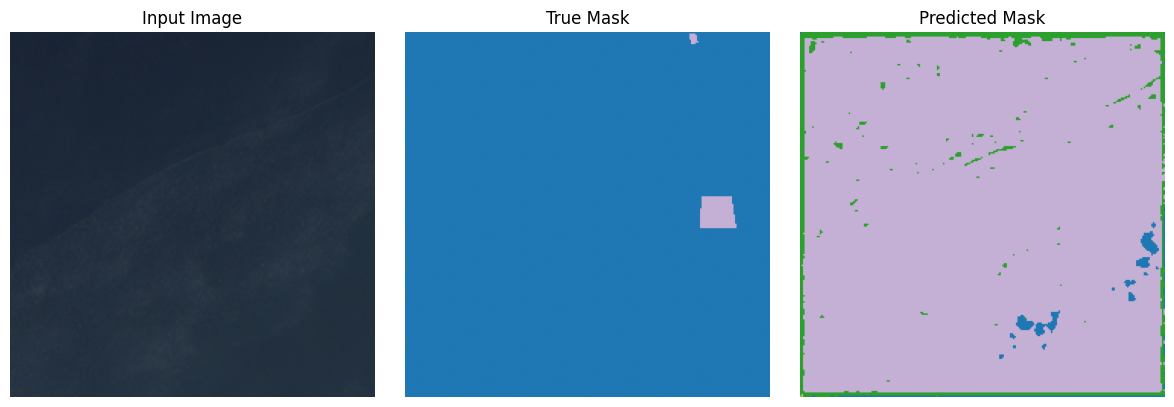

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


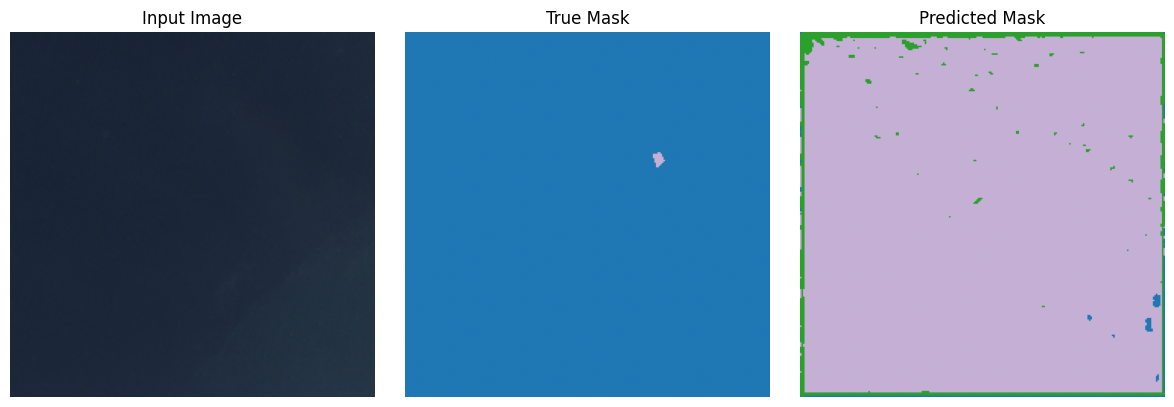

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


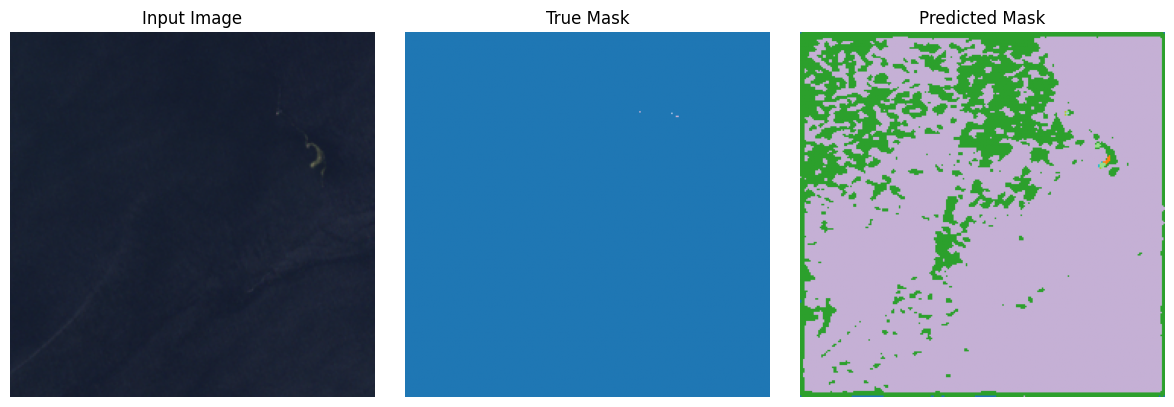

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


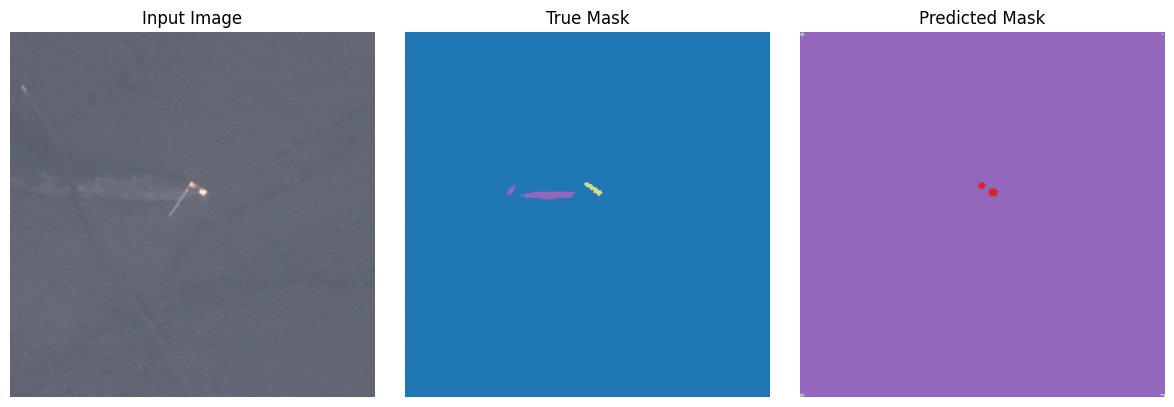

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


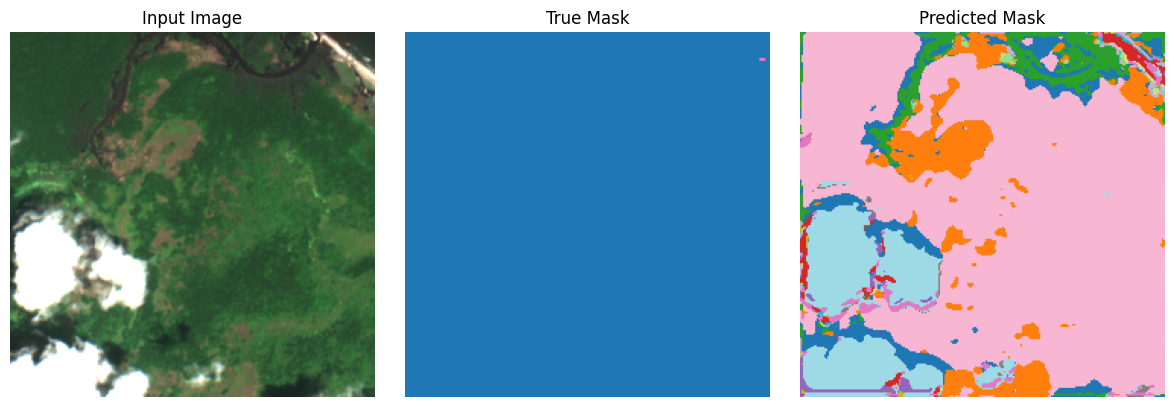

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


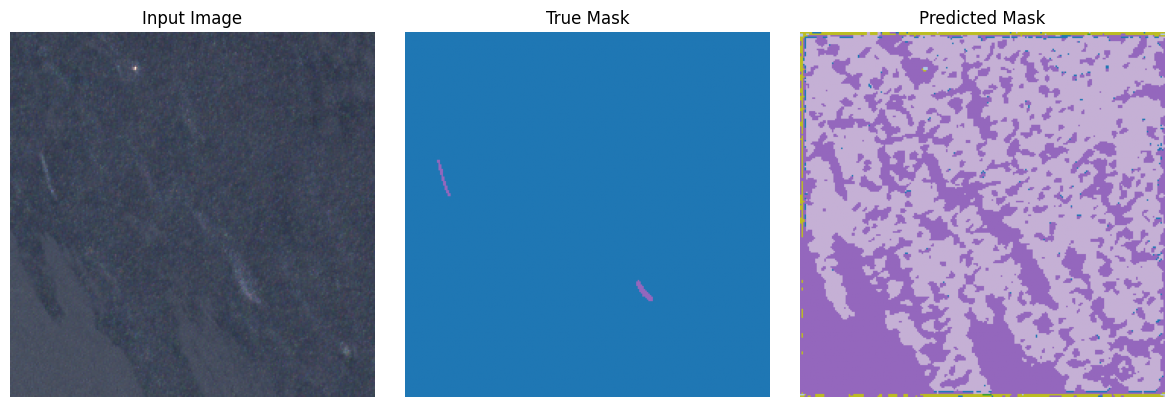

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


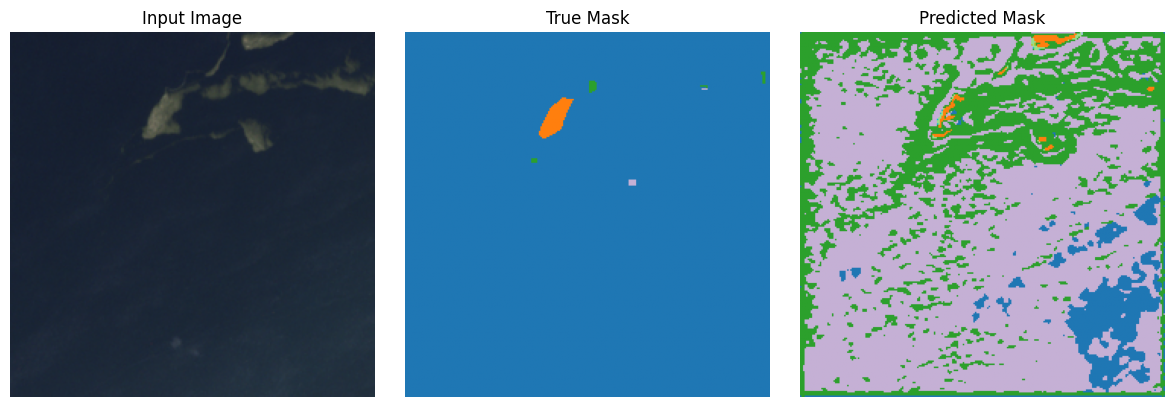

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


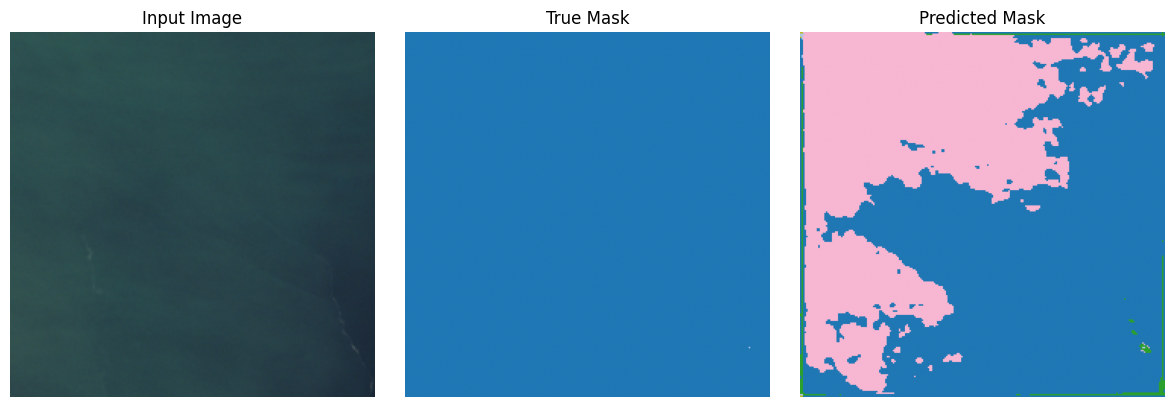

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


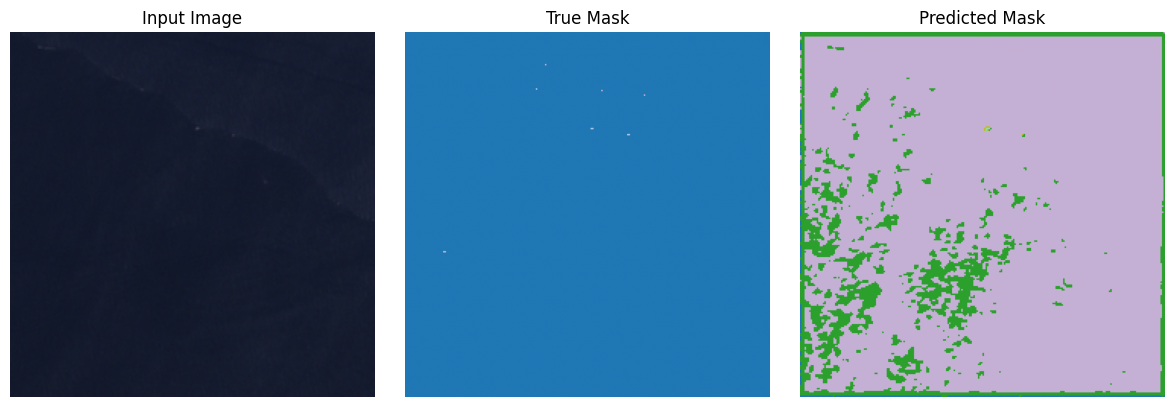

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


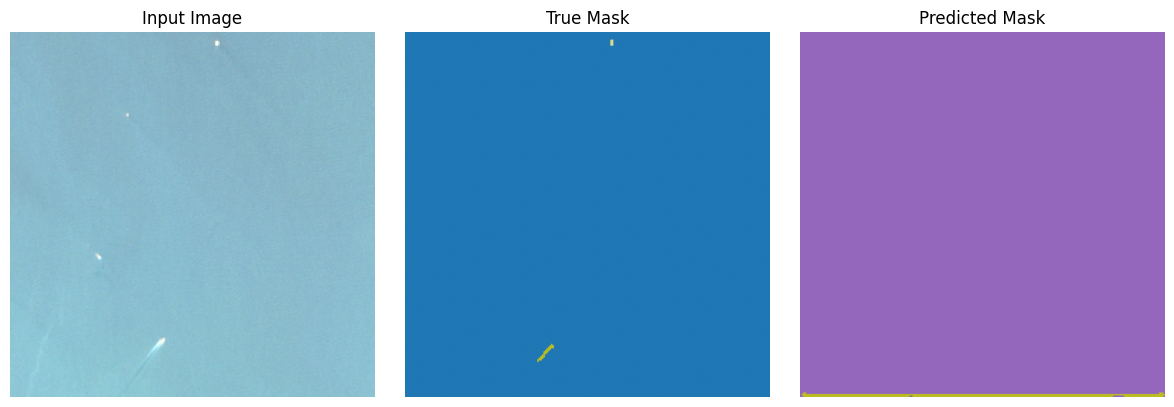

In [5]:
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

model = load_model("mados_unet_model.keras", custom_objects={"weighted_loss": weighted_loss, "CustomMeanIoU": lambda: CustomMeanIoU(num_classes=16)})

val_ds = create_dataset(os.path.join(SPLITS_DIR, "val_X.txt"), batch_size=1)

for image, true_mask in val_ds.take(10):  # Limit to 5 for speed
    pred_mask = model.predict(image)[0]
    pred_mask = np.argmax(pred_mask, axis=-1)

    image_np = image[0].numpy()
    true_mask_np = true_mask[0].numpy()

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.title("Input Image")
    plt.imshow(image_np)
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("True Mask")
    plt.imshow(true_mask_np, cmap="tab20", vmin=0, vmax=15)
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title("Predicted Mask")
    plt.imshow(pred_mask, cmap="tab20", vmin=0, vmax=15)
    plt.axis("off")

    plt.tight_layout()
    plt.show()
